# Spaceship Titanic 생존자 예측. 
작성자: 오성우

## 목차

1. [EDA + Preprocessing](##1. EDA + Preprocessing)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 1. EDA + Preprocessing

In [23]:
import os
from os.path import join
from pathlib import Path
data_dir = Path('./data')

train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

train.shape

(8693, 14)

In [24]:
test.shape

(4277, 13)

### 데이터를 확인합니다

#### 직관적으로 꼭 필요해보이는것
HomePlanet - 출발위치
Destination - 목적지
결국 이것이 경로가되어 차원이동이 필요한지가 결정될수 있음.

CryoSleep - 동면 격리 여부
차원이동 할때 필요할지도?

----------------------------------------------------
#### 나머지 고려사항

Cabin - deck/num/side

PassengerId - gggg_pp 형태 gggg=그룹 pp=승객

deck

side P(좌측) S(우측)

Age

VIP

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck

----------------------------------------------------
#### 필요 없어 보이는것


Name 

----------------------------------------------------

Transported - 차원이동 여부 (우리가 찾아야하는 값)

In [25]:
train.head(30)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


### 1-1 Missing Data 결측치
결측치가 너무 많네요ㅠ

In [26]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


#### 1-1-1 먼저 기내에서 돈을 쓴사람은 동면상태가 아니라고 채워줌

In [27]:
# 1. 지출 관련 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 지출 합계 계산 (결측치는 0으로 간주하고 합산)
total_spend = train[exp_cols].sum(axis=1)

# 3. CryoSleep이 결측치이면서, 지출 합계가 0보다 큰 경우 False로 채움
train.loc[train['CryoSleep'].isnull() & (total_spend > 0), 'CryoSleep'] = False
test.loc[test['CryoSleep'].isnull() & (total_spend > 0), 'CryoSleep'] = False

#### 1-1-2 동면중인사람은 지출을 모두 0으로 처리

In [28]:
for col in exp_cols:
    train.loc[(train['CryoSleep'] == True) & (train[col].isnull()), col] = 0
    test.loc[(test['CryoSleep'] == True) & (test[col].isnull()), col] = 0

In [29]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep        98
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
dtype: int64


#### 1-1-3 id의 그룹정보를 가지고 출발지 HomePlanet Destination 통일시키기

In [30]:
# PassengerId의 앞 4자리를 추출하여 'Group' 컬럼 생성
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0])
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0])

# 각 그룹별로 가장 많이 나타나는 HomePlanet과 Destination을 찾아 매칭
for col in ['HomePlanet', 'Destination']:
    # 그룹별 최빈값으로 결측치를 채움 (그룹 내 정보가 있는 경우)
    train[col] = train[col].fillna(train.groupby('Group')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))
    test[col] = test[col].fillna(test.groupby('Group')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

#### 1-1-4 HomePlanet, Destination, VIP의 전체 최빈값 구하기

In [31]:
hp_mode = train['HomePlanet'].mode()[0]
dest_mode = train['Destination'].mode()[0]
vip_mode = train['VIP'].mode()[0]
print( hp_mode, dest_mode, vip_mode)

Earth TRAPPIST-1e False


#### 1-1-5 VIP 는 일정금액이상 지출한사람은 true로 처리 아닌사람은 모두 False

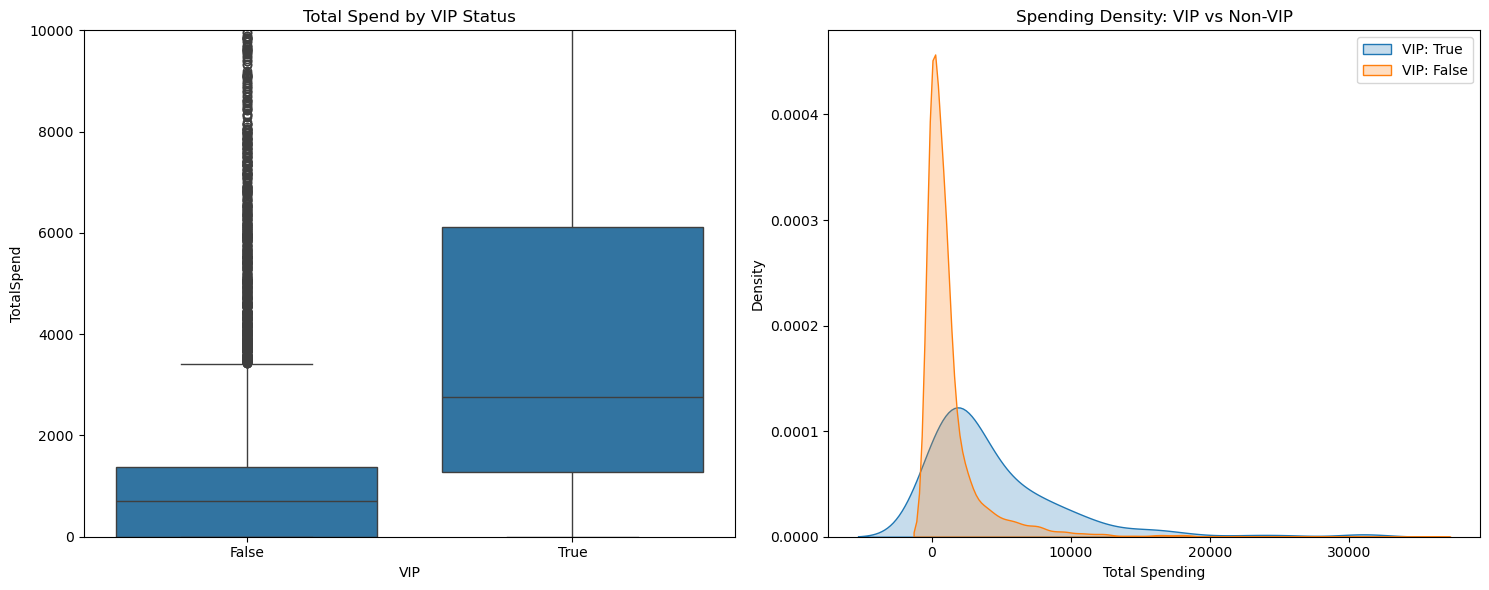

In [32]:
# 1. 이미 계산된 total_spend 변수를 train 데이터프레임에 삽입
train['TotalSpend'] = total_spend

# 2. 시각화 설정
plt.figure(figsize=(15, 6))

# [그래프 1] VIP 여부에 따른 지출 분포 (Boxplot)
plt.subplot(1, 2, 1)
# y축 값을 'TotalSpend' 컬럼으로 지정
sns.boxplot(data=train.dropna(subset=['VIP']), x='VIP', y='TotalSpend')
plt.title('Total Spend by VIP Status')
plt.ylim(0, 10000) # 데이터 분포에 따라 범위를 조절해 보세요.

# [그래프 2] 지출액에 따른 VIP 밀도 (KDE Plot)
plt.subplot(1, 2, 2)
# 각 VIP 조건에 맞는 데이터의 'TotalSpend'를 x축으로 시각화
sns.kdeplot(data=train[train['VIP'] == True], x='TotalSpend', label='VIP: True', fill=True)
sns.kdeplot(data=train[train['VIP'] == False], x='TotalSpend', label='VIP: False', fill=True)
plt.title('Spending Density: VIP vs Non-VIP')
plt.xlabel('Total Spending')
plt.legend()

plt.tight_layout()
plt.show()

Train VIP 지출확인

In [33]:
# 1. VIP와 Non-VIP 데이터 분리 (결측치 제외)
vip_true = train[train['VIP'] == True]
vip_false = train[train['VIP'] == False]

# 2. 전체 숫자 파악
total_vip_count = len(vip_true)
total_non_vip_count = len(vip_false)

print(f"--- [VIP 분석 (총 {total_vip_count}명)] ---")
# 1-1. 4000 이상 지출한 VIP 비율
v_over_4000 = len(vip_true[vip_true['TotalSpend'] >= 4000])
print(f"1. 4000이상 지출 VIP: {v_over_4000}명 / 비율: {v_over_4000/total_vip_count:.2%}")

# 1-2. 4000 이하 지출한 VIP 비율
v_under_4000 = len(vip_true[vip_true['TotalSpend'] < 4000])
print(f"2. 4000미만 지출 VIP: {v_under_4000}명 / 비율: {v_under_4000/total_vip_count:.2%}")

# 1-3. 2000 이하 지출한 VIP 비율
v_under_2000 = len(vip_true[vip_true['TotalSpend'] < 2000])
print(f"3. 2000미만 지출 VIP: {v_under_2000}명 / 비율: {v_under_2000/total_vip_count:.2%}")

print(f"\n--- [Non-VIP 분석 (총 {total_non_vip_count}명)] ---")
# 2-1. 4000 이상 지출한 Non-VIP 비율
nv_over_4000 = len(vip_false[vip_false['TotalSpend'] >= 4000])
print(f"1. 4000이상 지출 Non-VIP: {nv_over_4000}명 / 비율: {nv_over_4000/total_non_vip_count:.2%}")

# 2-2. 4000 이하 지출한 Non-VIP 비율
nv_under_4000 = len(vip_false[vip_false['TotalSpend'] < 4000])
print(f"2. 4000미만 지출 Non-VIP: {nv_under_4000}명 / 비율: {nv_under_4000/total_non_vip_count:.2%}")

# 2-3. 2000 이하 지출한 Non-VIP 비율
nv_under_2000 = len(vip_false[vip_false['TotalSpend'] < 2000])
print(f"3. 2000미만 지출 Non-VIP: {nv_under_2000}명 / 비율: {nv_under_2000/total_non_vip_count:.2%}")

--- [VIP 분석 (총 199명)] ---
1. 4000이상 지출 VIP: 73명 / 비율: 36.68%
2. 4000미만 지출 VIP: 126명 / 비율: 63.32%
3. 2000미만 지출 VIP: 80명 / 비율: 40.20%

--- [Non-VIP 분석 (총 8291명)] ---
1. 4000이상 지출 Non-VIP: 739명 / 비율: 8.91%
2. 4000미만 지출 Non-VIP: 7552명 / 비율: 91.09%
3. 2000미만 지출 Non-VIP: 6773명 / 비율: 81.69%


Test VIP 지출 확인

In [34]:
# 0. Test용 TotalSpend 열 생성
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test['TotalSpend'] = test[exp_cols].sum(axis=1)

# 1. VIP와 Non-VIP 데이터 분리 (test 데이터 기준, 결측치 제외)
vip_true_test = test[test['VIP'] == True]
vip_false_test = test[test['VIP'] == False]

# 2. 전체 숫자 파악
total_vip_count_test = len(vip_true_test)
total_non_vip_count_test = len(vip_false_test)

print(f"--- [TEST 세트 VIP 분석 (총 {total_vip_count_test}명)] ---")
if total_vip_count_test > 0:
    # 1-1. 4000 이상 지출한 VIP 비율
    v_over_4000 = len(vip_true_test[vip_true_test['TotalSpend'] >= 4000])
    print(f"1. 4000이상 지출 VIP: {v_over_4000}명 / 비율: {v_over_4000/total_vip_count_test:.2%}")

    # 1-2. 4000 이하 지출한 VIP 비율
    v_under_4000 = len(vip_true_test[vip_true_test['TotalSpend'] < 4000])
    print(f"2. 4000미만 지출 VIP: {v_under_4000}명 / 비율: {v_under_4000/total_vip_count_test:.2%}")

    # 1-3. 2000 이하 지출한 VIP 비율
    v_under_2000 = len(vip_true_test[vip_true_test['TotalSpend'] < 2000])
    print(f"3. 2000미만 지출 VIP: {v_under_2000}명 / 비율: {v_under_2000/total_vip_count_test:.2%}")
else:
    print("VIP 데이터가 없습니다.")

print(f"\n--- [TEST 세트 Non-VIP 분석 (총 {total_non_vip_count_test}명)] ---")
if total_non_vip_count_test > 0:
    # 2-1. 4000 이상 지출한 Non-VIP 비율
    nv_over_4000 = len(vip_false_test[vip_false_test['TotalSpend'] >= 4000])
    print(f"1. 4000이상 지출 Non-VIP: {nv_over_4000}명 / 비율: {nv_over_4000/total_non_vip_count_test:.2%}")

    # 2-2. 4000 이하 지출한 Non-VIP 비율
    nv_under_4000 = len(vip_false_test[vip_false_test['TotalSpend'] < 4000])
    print(f"2. 4000미만 지출 Non-VIP: {nv_under_4000}명 / 비율: {nv_under_4000/total_non_vip_count_test:.2%}")

    # 2-3. 2000 이하 지출한 Non-VIP 비율
    nv_under_2000 = len(vip_false_test[vip_false_test['TotalSpend'] < 2000])
    print(f"3. 2000미만 지출 Non-VIP: {nv_under_2000}명 / 비율: {nv_under_2000/total_non_vip_count_test:.2%}")
else:
    print("Non-VIP 데이터가 없습니다.")

--- [TEST 세트 VIP 분석 (총 74명)] ---
1. 4000이상 지출 VIP: 29명 / 비율: 39.19%
2. 4000미만 지출 VIP: 45명 / 비율: 60.81%
3. 2000미만 지출 VIP: 27명 / 비율: 36.49%

--- [TEST 세트 Non-VIP 분석 (총 4110명)] ---
1. 4000이상 지출 Non-VIP: 337명 / 비율: 8.20%
2. 4000미만 지출 Non-VIP: 3773명 / 비율: 91.80%
3. 2000미만 지출 Non-VIP: 3372명 / 비율: 82.04%


#### 2000이상 지출한사람은 VIP 아닌사람은 NonVIP로 결측치 채우기

In [35]:
train.loc[train['VIP'].isnull() & (train['TotalSpend'] > 2000), 'VIP'] = True
train['VIP'] = train['VIP'].fillna(False)

test.loc[test['VIP'].isnull() & (test['TotalSpend'] > 2000), 'VIP'] = True
test['VIP'] = test['VIP'].fillna(False)

#### VIP인사람 혹은 아닌사람 각 지출별 평균값으로 설정

In [40]:
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for vip_status in [True, False]:
    for col in exp_cols:
        # 평균값은 항상 'train' 데이터 기준으로 계산하여 일관성 유지
        mean_val = train[train['VIP'] == vip_status][col].mean()
        train.loc[(train['CryoSleep'] == False) & (train['VIP'] == vip_status) & (train[col].isnull()), col] = mean_val

# [TRAIN] 3단계: 남은 결측치(VIP가 NaN이었던 경우 등) 0으로 마무리 및 합계 갱신
train[exp_cols] = train[exp_cols].fillna(0)
train['TotalSpend'] = train[exp_cols].sum(axis=1)

In [41]:
for vip_status in [True, False]:
    for col in exp_cols:
        # 중요: test의 결측치를 채울 때도 'train'의 평균값을 사용하는 것이 머신러닝의 정석입니다.
        mean_val = train[train['VIP'] == vip_status][col].mean()
        test.loc[(test['CryoSleep'] == False) & (test['VIP'] == vip_status) & (test[col].isnull()), col] = mean_val

# [TEST] 3단계: 남은 결측치 0으로 마무리 및 합계 갱신
test[exp_cols] = test[exp_cols].fillna(0)
test['TotalSpend'] = test[exp_cols].sum(axis=1)

In [42]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep        66
Cabin           199
Destination     103
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
dtype: int64


### 1-1-5-2 아직도 CryoSleep이 66이남았네요 이동거리를 예측할방법 있을까요? 먼저 동면상태에따른 이동경로를 확인해보고 특이점이 없다면 지출한 금액을 기준을 대신하여 장기간 이동여부를 예측하고 이에따라 CryoSleep 나머지를 채워주도록할게요

--- [경로별 동면(CryoSleep) 비율 (%)] ---
CryoSleep                    False      True 
Route                                        
Earth to 55 Cancri e     69.855072  30.144928
Earth to PSO J318.5-22   50.209205  49.790795
Earth to TRAPPIST-1e     72.987591  27.012409
Europa to 55 Cancri e    49.440716  50.559284
Europa to PSO J318.5-22  52.631579  47.368421
Europa to TRAPPIST-1e    61.429759  38.570241
Mars to 55 Cancri e      59.278351  40.721649
Mars to PSO J318.5-22    77.551020  22.448980
Mars to TRAPPIST-1e      61.206897  38.793103


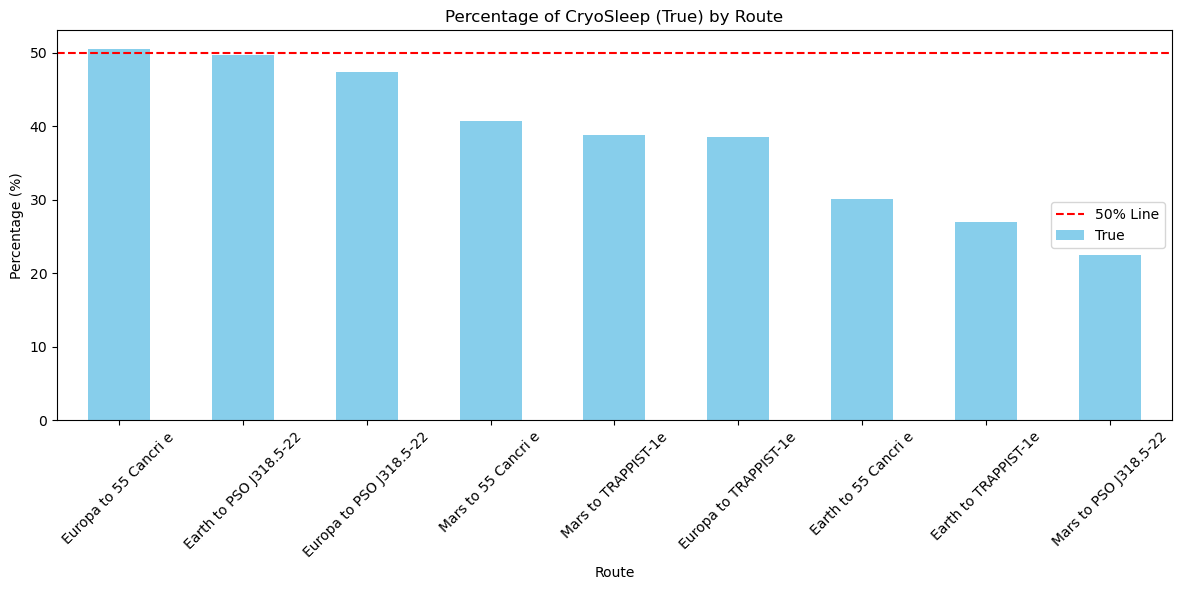

In [43]:
# 1. 이동 경로(Route) 컬럼 생성
train['Route'] = train['HomePlanet'] + " to " + train['Destination']

# 2. 경로별 동면 비율 계산
# 각 경로(Route) 내에서 CryoSleep의 True/False 비율을 구합니다.
route_cryo_pivot = train.groupby('Route')['CryoSleep'].value_counts(normalize=True).unstack() * 100

# 결측치를 0으로 채워 보기 좋게 정렬
route_cryo_pivot = route_cryo_pivot.fillna(0)

print("--- [경로별 동면(CryoSleep) 비율 (%)] ---")
print(route_cryo_pivot)

# 3. 시각화 (어떤 경로에서 동면을 많이 하는가?)
plt.figure(figsize=(12, 6))
route_cryo_pivot[True].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.axhline(y=50, color='r', linestyle='--', label='50% Line')
plt.title('Percentage of CryoSleep (True) by Route')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
### 1-1-5-3 경로별 지출내역도 확인

--- [경로별 TotalSpend 분석] ---
                                mean       median  count
Route                                                   
Europa to PSO J318.5-22  4139.337214  1894.030435     19
Europa to 55 Cancri e    3631.698880     0.000000    905
Europa to TRAPPIST-1e    3301.733370  2152.000000   1221
Mars to 55 Cancri e      1188.184003   783.000000    197
Mars to PSO J318.5-22    1057.624041   912.500000     50
Mars to TRAPPIST-1e      1055.370355   955.000000   1525
Earth to TRAPPIST-1e      750.644484   783.000000   3143
Earth to 55 Cancri e      639.988653   652.000000    697
Earth to PSO J318.5-22    473.190827     0.000000    725


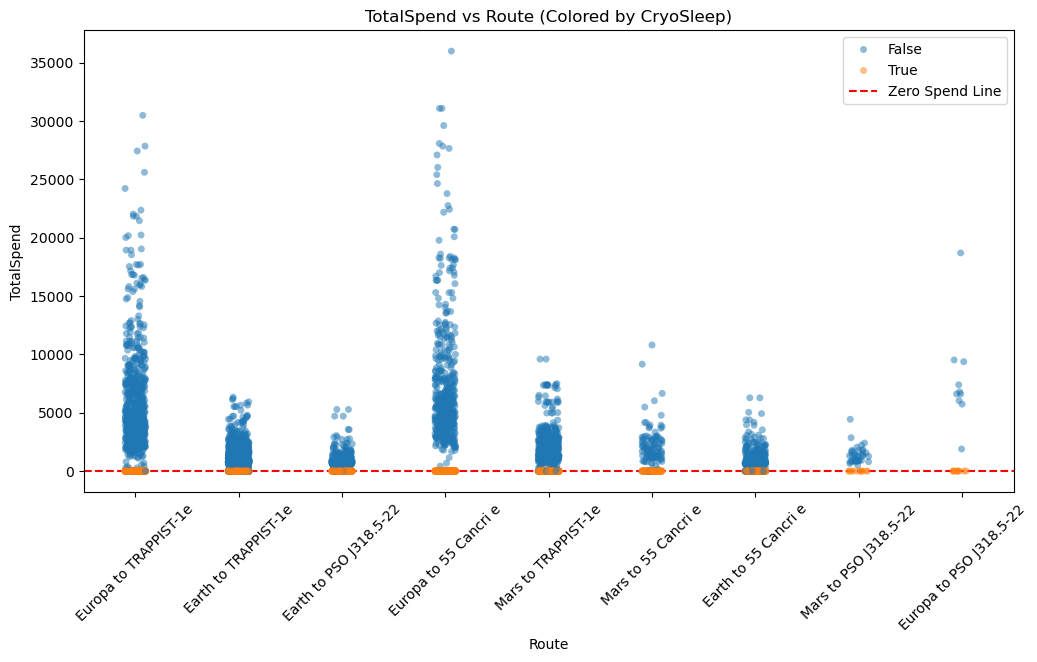

In [46]:
# 1. 경로별 지출 통계 (평균 지출액 중심)
# TotalSpend가 높은 경로일수록 '지출 0'인 승객이 동면(CryoSleep)일 확률이 급격히 높아집니다.
route_spend_analysis = train.groupby('Route')['TotalSpend'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

print("--- [경로별 TotalSpend 분석] ---")
print(route_spend_analysis)

# 2. 시각화: 지출액과 동면 여부의 상관관계 확인
plt.figure(figsize=(12, 6))
sns.stripplot(data=train, x='Route', y='TotalSpend', hue='CryoSleep', jitter=True, alpha=0.5)
plt.title('TotalSpend vs Route (Colored by CryoSleep)')
plt.xticks(rotation=45)
plt.axhline(y=1, color='r', linestyle='--', label='Zero Spend Line') # 지출 0원 선
plt.legend()
plt.show()

### 두 그래 프 분석
동면 vs 경로를 보면 경로마다 큰차이가 없어보이고
지출 vs 경로를 보면 경로마다 뚜렷한 큰 차이가 보입니다. 제 직관에 의하면 지출이 거리랑 관련이 클것같습니다. 하지만 이미 지출값은 평균값으로 채웠고

이제 동면여부는 다른방법을 생각해야겠네요...

출발지와 도착지만가지고 비교를 해봐야겠네요

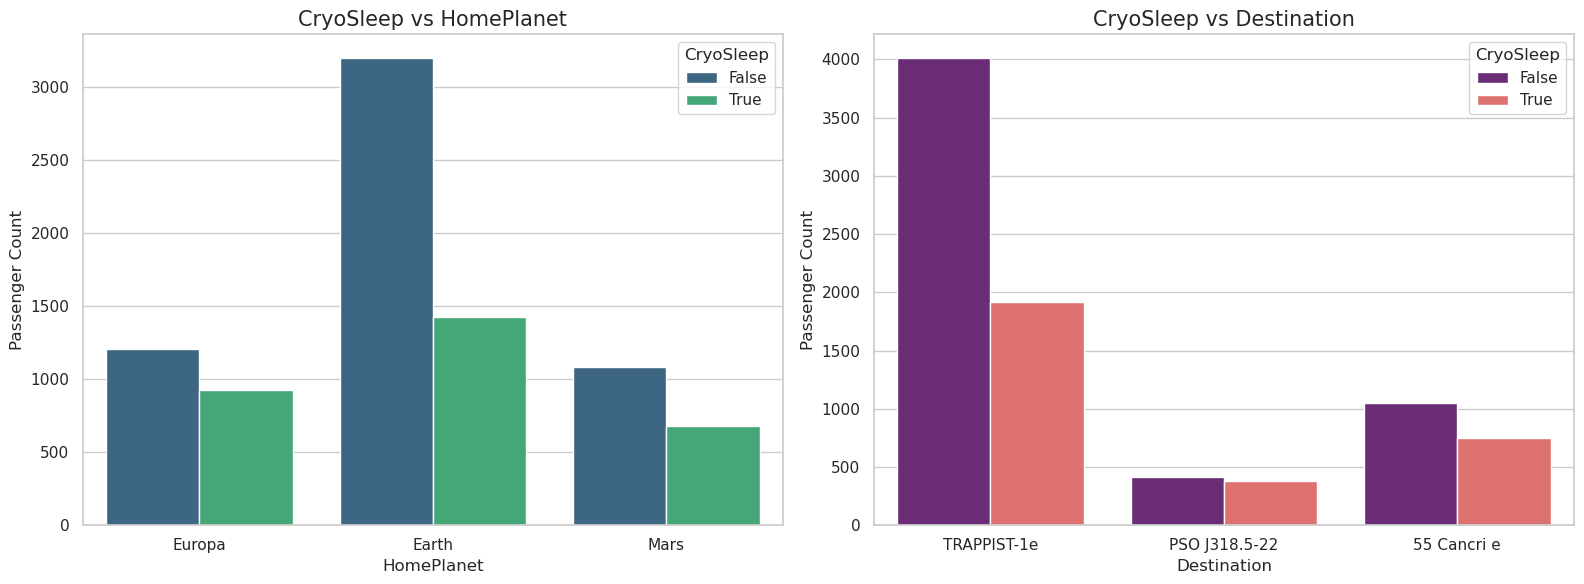

In [47]:
# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# [그래프 1] 출발지(HomePlanet)별 동면 여부
plt.subplot(1, 2, 1)
sns.countplot(data=train, x='HomePlanet', hue='CryoSleep', palette='viridis')
plt.title('CryoSleep vs HomePlanet', fontsize=15)
plt.xlabel('HomePlanet')
plt.ylabel('Passenger Count')

# [그래프 2] 도착지(Destination)별 동면 여부
plt.subplot(1, 2, 2)
sns.countplot(data=train, x='Destination', hue='CryoSleep', palette='magma')
plt.title('CryoSleep vs Destination', fontsize=15)
plt.xlabel('Destination')
plt.ylabel('Passenger Count')

plt.tight_layout()
plt.show()

#### 대략 출발지가 Earth이거나 도착지가 TRAPPIST-1e면 동면 True 아니면 False로 하면 될거같네요

In [48]:
# train 데이터 처리
# 조건: (동면 여부가 NaN) AND (출발지가 Earth 이거나 도착지가 TRAPPIST-1e)
mask_train = (train['CryoSleep'].isnull()) & ((train['HomePlanet'] == 'Earth') | (train['Destination'] == 'TRAPPIST-1e'))
train.loc[mask_train, 'CryoSleep'] = True

train['CryoSleep'] = train['CryoSleep'].fillna(False)


# test 데이터 처리 (일관성을 위해 동일 로직 적용)
mask_test = (test['CryoSleep'].isnull()) & ((test['HomePlanet'] == 'Earth') | (test['Destination'] == 'TRAPPIST-1e'))
test.loc[mask_test, 'CryoSleep'] = True

test['CryoSleep'] = test['CryoSleep'].fillna(False)

print(f"train CryoSleep 결측치 남은 수: {train['CryoSleep'].isnull().sum()}")
print(f"test CryoSleep 결측치 남은 수: {test['CryoSleep'].isnull().sum()}")

train CryoSleep 결측치 남은 수: 0
test CryoSleep 결측치 남은 수: 0


In [49]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep         0
Cabin           199
Destination     103
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
Route           211
dtype: int64


#### 1-1-6 멀리 돌아왔네요 -_- 다시 HomePlanet Destination으로..


===== [ HomePlanet 분석 ] =====

> 동면 중 (True):
  - Earth: 46.35%
  - Europa: 30.91%
  - Mars: 22.74%

> 깨어 있음 (False):
  - Earth: 58.29%
  - Europa: 21.95%
  - Mars: 19.76%

===== [ Destination 분석 ] =====

> 동면 중 (True):
  - 55 Cancri e: 24.77%
  - PSO J318.5-22: 12.72%
  - TRAPPIST-1e: 62.52%

> 깨어 있음 (False):
  - 55 Cancri e: 19.13%
  - PSO J318.5-22: 7.53%
  - TRAPPIST-1e: 73.34%


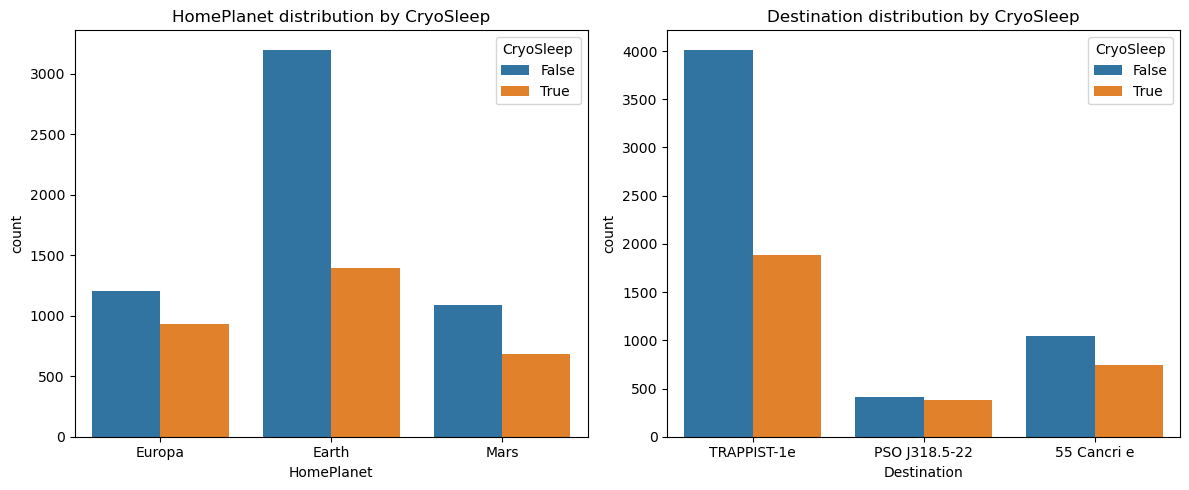

In [37]:
# 분석할 컬럼 리스트
cols_to_analyze = ['HomePlanet', 'Destination']

for col in cols_to_analyze:
    print(f"\n===== [ {col} 분석 ] =====")
    
    # CryoSleep 그룹별로 해당 컬럼의 비율 계산
    # .value_counts(normalize=True)를 사용하면 바로 % 비율이 나옵니다.
    analysis = train.groupby('CryoSleep')[col].value_counts(normalize=True).unstack() * 100
    
    # 출력 포맷팅
    for sleep_status in [True, False]:
        status_text = "동면 중 (True)" if sleep_status else "깨어 있음 (False)"
        print(f"\n> {status_text}:")
        
        # 각 행성별 비율 출력
        for planet, percent in analysis.loc[sleep_status].dropna().items():
            print(f"  - {planet}: {percent:.2f}%")

plt.figure(figsize=(12, 5))
for i, col in enumerate(cols_to_analyze):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=train, x=col, hue='CryoSleep')
    plt.title(f'{col} distribution by CryoSleep')
plt.tight_layout()
plt.show()

다른 출발지와 도착지는 특징을 못찾았는데 출발지가 Earth 이고 도착지가 TRAPPIST-1e 면 66%가 동면이고 33%가 동면아님. 다른 출발지랑 목적지는 크게 차이안남.

In [38]:
# 1. Earth -> TRAPPIST-1e 경로인 승객 중 CryoSleep이 NaN인 경우
# 확률이 66%로 높으므로 True로 채워주는 전략을 쓸 수 있습니다.
mask = (train['HomePlanet'] == 'Earth') & (train['Destination'] == 'TRAPPIST-1e') & (train['CryoSleep'].isnull())
train.loc[mask, 'CryoSleep'] = True

# test 데이터에도 동일하게 적용
mask_test = (test['HomePlanet'] == 'Earth') & (test['Destination'] == 'TRAPPIST-1e') & (test['CryoSleep'].isnull())
test.loc[mask_test, 'CryoSleep'] = True

In [39]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep        66
Cabin           199
Destination     103
Age             179
VIP               0
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
Group             0
TotalSpend        0
dtype: int64


In [ ]:
#----------------------------------------------------------------------------------------------

In [6]:
# 자료형 확인
features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Cabin']
print(train[features].dtypes)

Pclass      int64
Sex        object
SibSp       int64
Parch       int64
Fare      float64
Cabin      object
dtype: object


### 통계치 확인
test 그룹이 조금 더 돈을내고 Pclass가 높음, 나이는 거의 비슷, SibSp는 작고 Parch는 거의같음.

In [7]:
# 통계치 확인
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### Cabin 데이터 수정?? (보류중)
Cabin 데이터 형태를봤을때 위치값에는 영향이있을것 같은데 형태가 C715 이런식이라 가공해줘야하는데 ABC를 숫자로대체했을때 오히려 오류가 커질수도 있을것같아서 보류

In [10]:
features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare'] # Cabin 제외함

In [11]:
print(train[features].dtypes)

Pclass      int64
Sex        object
SibSp       int64
Parch       int64
Fare      float64
dtype: object


#### 성별을 원핫인코딩하기전에 먼저 필요한지 재확인

In [12]:
sex_survival = train.groupby('Sex')['Survived'].mean()
print(sex_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [13]:
#다른 데이터들도 재확인
for col in features:
    print(f"--- {col} 별 통계 ---")
    # mean은 생존율, count는 전체 승객 수(아이템 수)
    stats = train.groupby(col)['Survived'].agg(['mean', 'count'])
    print(stats)
    print("\n")

--- Pclass 별 통계 ---
            mean  count
Pclass                 
1       0.629630    216
2       0.472826    184
3       0.242363    491


--- Sex 별 통계 ---
            mean  count
Sex                    
female  0.742038    314
male    0.188908    577


--- SibSp 별 통계 ---
           mean  count
SibSp                 
0      0.345395    608
1      0.535885    209
2      0.464286     28
3      0.250000     16
4      0.166667     18
5      0.000000      5
8      0.000000      7


--- Parch 별 통계 ---
           mean  count
Parch                 
0      0.343658    678
1      0.550847    118
2      0.500000     80
3      0.600000      5
4      0.000000      4
5      0.200000      5
6      0.000000      1


--- Fare 별 통계 ---
              mean  count
Fare                     
0.0000    0.066667     15
4.0125    0.000000      1
5.0000    0.000000      1
6.2375    0.000000      1
6.4375    0.000000      1
...            ...    ...
227.5250  0.750000      4
247.5208  0.500000      2
262.3750 

### 1-2 Feature 별 분석

#### Pclass
상식적으로 더좋은좌석이 더안전할것같은데 결과도 상식과 일치하게 나옴. 우리가 반드시 가져가야할 요소
#### Sex
극적인 차이를 보이므로 둘중하나임. 좋은 모델이 되거나, 과적합이되거나.
#### SipSp Parch
동반자가 0명일땐 두경우 모두 34%의생존율을 보이고 1명일땐 54%/55%로 가장 높은생존율을보임
그이후로는 동반자 수가 늘어날수록 생존율이떨어지는 경향이 있긴한데 3명 이상일경우엔 count가 너무적어서 이상치 처리를 해줘야될수도
#### Fare
이건 그래프로 봐야할것같음

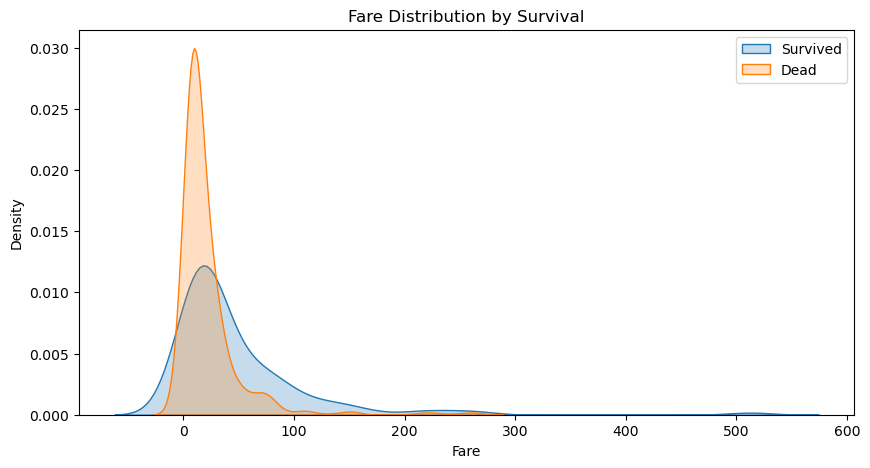

In [14]:
plt.figure(figsize=(10, 5))
sns.kdeplot(train[train['Survived'] == 1]['Fare'], label='Survived', shade=True)
sns.kdeplot(train[train['Survived'] == 0]['Fare'], label='Dead', shade=True)
plt.title('Fare Distribution by Survival')
plt.legend()
plt.show()

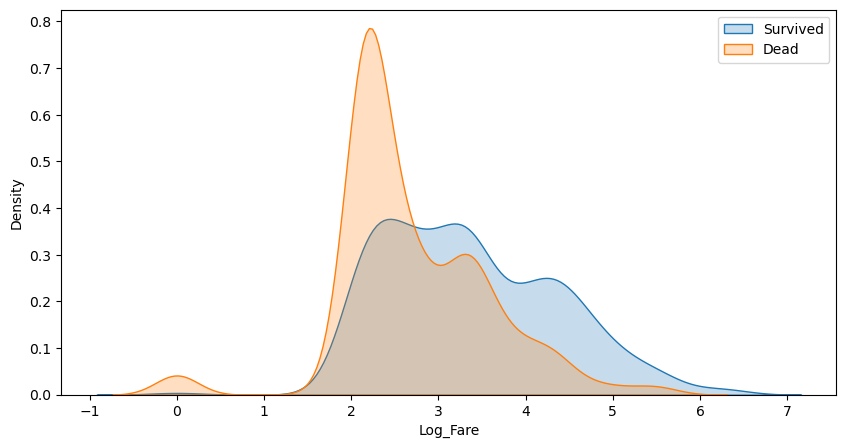

In [15]:
# 산이 왼쪽으로 쏠려있으니 로그변환 해서 다시확인
train['logFare'] = train['Fare'].apply(np.log1p)

plt.figure(figsize=(10, 5))
sns.kdeplot(train[train['Survived'] == 1]['logFare'], label='Survived', shade=True)
sns.kdeplot(train[train['Survived'] == 0]['logFare'], label='Dead', shade=True)
plt.legend()
plt.show()

### 1-3 Fare (Feature 분석) 
대략 돈을 50 이하로쓴사람들중엔 사망자가 더많고 100이상 쓴사람들중엔 생존자가 더많음. 필요한포인트
그리고 값 스케일도 SibSp, Parch와 비슷해서 그냥 로그변환후 별다른 스케일변환없이 사용

### 1-4 혼자왔는가? 열 추가
1-1에서 분석했듯 형제자매나 자식 부모가 없는경우 분명히 생존율이 낮아짐.

In [17]:
train['IsAlone'] = 0
train.loc[(train['SibSp'] + train['Parch']) == 0, 'IsAlone'] = 1

#확인용
print(train[['SibSp', 'Parch', 'IsAlone']].head())

   SibSp  Parch  IsAlone
0      1      0        0
1      1      0        0
2      0      0        1
3      1      0        0
4      0      0        1


### 1-5 Sex 숫자로 변환

In [18]:
train['nSex'] = train['Sex'].map({'female': 0, 'male': 1})

In [19]:
# Cabin 제외함
# Sex, Fare 제외함
# SibSp Parch는 유지
features = ['Pclass', 'nSex', 'SibSp', 'Parch', 'Fare', 'IsAlone'] # nSex, IsAlone 추가

### 1-6 SibSp Parch Outlier 분석 및 처리

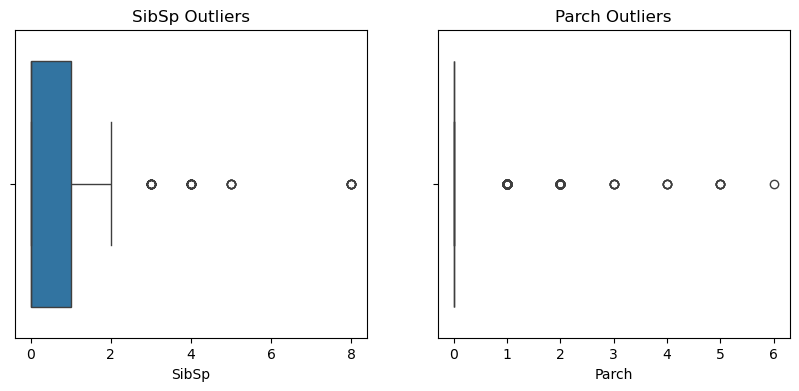

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=train['SibSp'])
plt.title('SibSp Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(x=train['Parch'])
plt.title('Parch Outliers')
plt.show()

### 1-6-2 FamilySize로 합치기
박스플롯을 그려보니 Parch의경우 1~2 값도 이상치로 간주될거같은데 앞서 1-1에서 분석했듯이. 두 데이터는 0에서 생존율이 가장낮고, 1일생존율이 올라갔다가 다시 2이상일경우 생존율이 점점 떨어지는 경향을 보입니다. 따라서 이값을 합쳐서 하나의 데이터로 만들어도 될것 같아요.

In [21]:
# 1. 본인 포함 가족 수 계산
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

# 2. 구간 나누기 (Binning)
# 1명: 혼자(Alone), 2~4명: 소가족(Small), 5명 이상: 대가족(Large)
def simplify_family(x):
    if x == 1: return 0      # Alone
    elif x <= 4: return 1    # Small
    else: return 2           # Large (이상치들이 여기로 모임)

train['FamilyGroup'] = train['FamilySize'].apply(simplify_family)

In [22]:
#features 정리
# IsAlone은 FamilySize == 1 일때와 같으니 중복되므로 삭제
# FamilyGroup 추가
# Sipsp, Parch 삭제
features = ['Pclass', 'nSex', 'Fare', 'FamilyGroup']

### 1-7 Age

In [23]:
survived_age_mean = train.groupby('Survived')['Age'].mean()

In [24]:
survived_age_mean

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

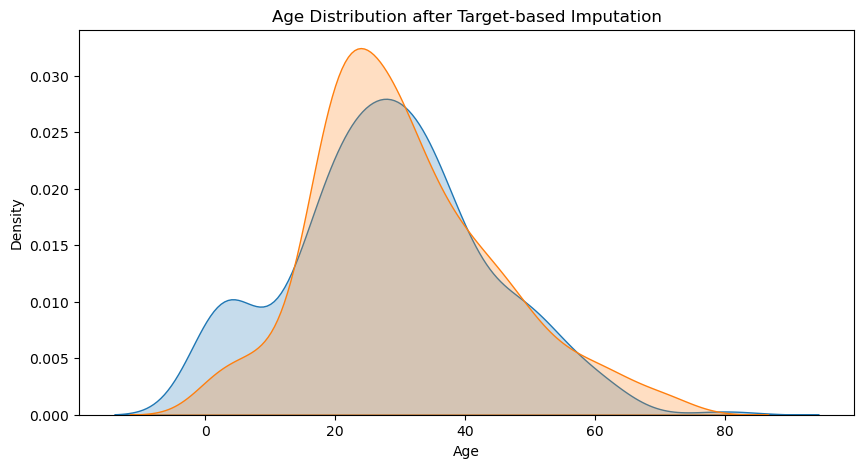

In [25]:
plt.figure(figsize=(10, 5))
sns.kdeplot(train[train['Survived'] == 1]['Age'], label='Survived', shade=True)
sns.kdeplot(train[train['Survived'] == 0]['Age'], label='Dead', shade=True)
plt.title('Age Distribution after Target-based Imputation')
plt.show()

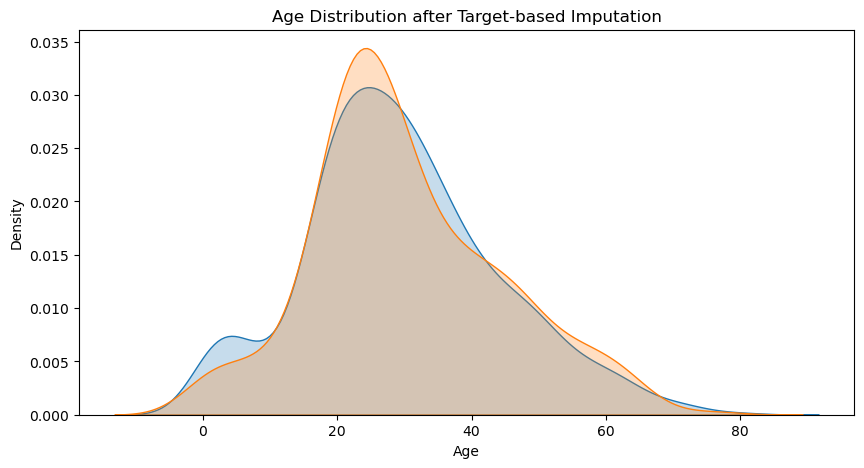

In [26]:
plt.figure(figsize=(10, 5))
sns.kdeplot(train['Age'], label='train', shade=True)
sns.kdeplot(test['Age'], label='test', shade=True)
plt.title('Age Distribution after Target-based Imputation')
plt.show()

### 1-7 Age 중간 정검
먼저 위 그래프에서 생존자vs사망자를 비교했더니 10세이하에서 생존자가 많고 20 - 30에서 사망자가 많았습니다.
구조할때 아이먼저라는 개념이 적용된것으로 예측이됩니다.
그리고 두번째 그래프에서는 훈련vs테스트 데이터를 비교했더니 훈련데이터에 10세이하가 더많고 테스트데이터에서는 20 - 30이 더많습니다.

우선 결측치를 채우고 위그래프와 다시 비교해볼게요

In [27]:
# 결측치를 Pclass와 Sex 중간값으로 채우기
train['Age'] = train['Age'].fillna(train.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
test['Age'] = test['Age'].fillna(test.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

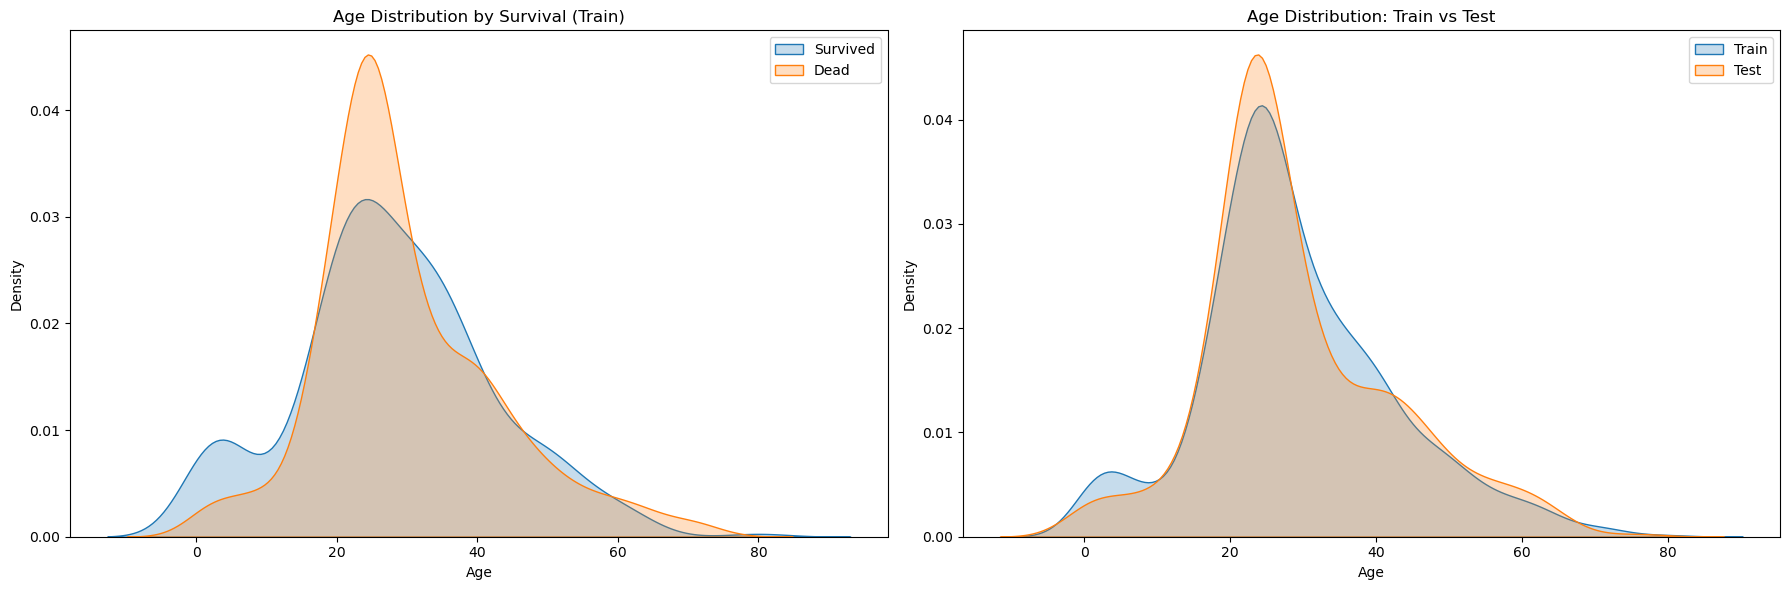

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 첫 번째 그래프: Train 데이터 내 생존 여부별 나이 분포
sns.kdeplot(train[train['Survived'] == 1]['Age'], label='Survived', shade=True, ax=ax[0])
sns.kdeplot(train[train['Survived'] == 0]['Age'], label='Dead', shade=True, ax=ax[0])
ax[0].set_title('Age Distribution by Survival (Train)')
ax[0].legend()

# 두 번째 그래프: Train vs Test 전체 나이 분포 비교
sns.kdeplot(train['Age'], label='Train', shade=True, ax=ax[1])
sns.kdeplot(test['Age'], label='Test', shade=True, ax=ax[1])
ax[1].set_title('Age Distribution: Train vs Test')
ax[1].legend()

plt.tight_layout() # 그래프 간 간격을 자동으로 맞춰줌
plt.show()

Train과 Test 분포차이가 기존과 큰차이가없네요. 이걸로 결측치가 크게 튀지않는 데이터로 채워졌다고 예상이되네요
생존자 사망자 는 생존자 사망자 차이가 더 두드러지도록 변화되었습니다.

In [29]:
#features 정리
# Age 추가
features = ['Pclass', 'nSex', 'Fare', 'FamilyGroup', 'Age']

## 1-7-2 Age Binning
바로위의 왼쪽 그래프를 보면 
15 이하의 생존율이 높고 
17-30정도까지는 사망자가 높습니다. (가장위험)
또 33-40은 생존자가 높고
그뒤로는 비슷하게 내려갑니다.

In [30]:
def get_age_category(age):
    if age <= 16: return 0     # 아동/청소년
    elif age <= 32: return 1   # 청년
    elif age <= 48: return 2   # 장년
    elif age <= 64: return 3   # 중년
    else: return 4             # 노년

train['Age_bin'] = train['Age'].apply(get_age_category)
test['Age_bin'] = test['Age'].apply(get_age_category)

#train.drop('Age', axis=1, inplace=True)
#test.drop('Age', axis=1, inplace=True)

In [31]:
features = ['Pclass', 'nSex', 'logFare', 'FamilyGroup', 'Age_bin']

In [32]:
train[features].head(20)

,Pclass,nSex,logFare,FamilyGroup,Age_bin
0,3,1,2.110213,1,1
1,1,0,4.280593,1,2
2,3,0,2.188856,0,1
3,1,0,3.990834,1,2
4,3,1,2.202765,0,2
5,3,1,2.246893,0,1
6,1,1,3.967694,0,3
7,3,1,3.094446,2,0
8,3,0,2.495954,1,1
9,2,0,3.436268,1,0


# 2 모델 학습

## 2-1 RandomForest
프로젝트때 동건님발표한것이 RMSE점수가높게나왔는데 검색해보니 RF는 값의 크기가 영향받지않는 모델이라 하여 이것부터 해보겠습니다.
따라서 정규화작업이 필요없습니다.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_train = train[features]
y_train = train['Survived']

# 모델 생성
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 교차 검증
scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"평균 정확도: {scores.mean():.4f}")

# 모델 학습
model.fit(X_train, y_train)

평균 정확도: 0.8126


,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


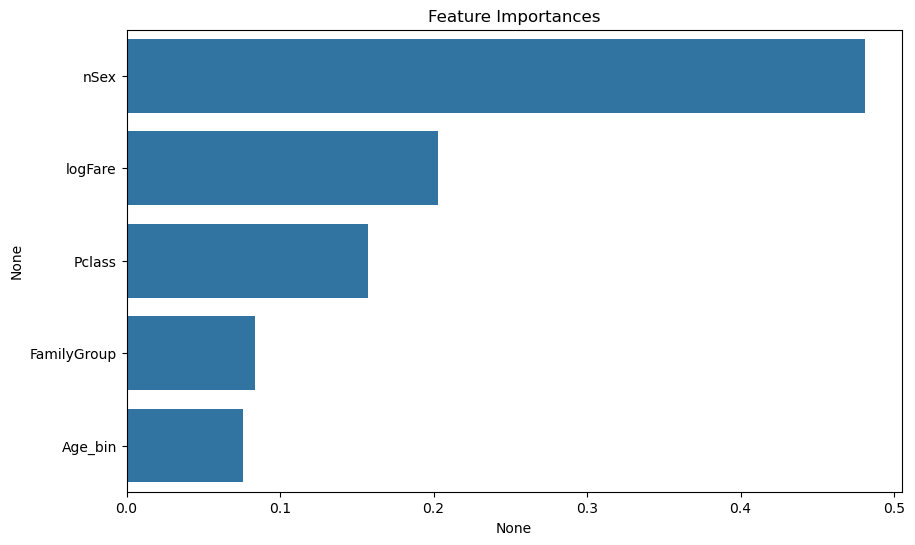

In [34]:
# 변수 중요도 추출
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title('Feature Importances')
plt.show()

## 2-2 RF + GridSearch 모델 훈련

In [35]:
from sklearn.model_selection import GridSearchCV

# 1. 테스트해볼 파라미터 범위 설정
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. 그리드 서치 모델 생성 (cv=5는 5번 교차 검증)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2)

# 3. 학습 시작 (모든 조합을 다 시도해봅니다)
grid_search.fit(X_train, y_train)

# 4. 결과 확인
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 5. 최적의 모델로 최종 예측
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.9s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.8s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.9s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=3, min_samples_leaf

In [36]:
pd.set_option('display.max_colwidth', None)

cv_results = pd.DataFrame(grid_search.cv_results_)
# 점수 높은 순으로 정렬해서 상위 5개 조합 보기
print(cv_results[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head())

                                                                                  params  \
59  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}   
65  {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}   
58  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}   
57  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}   
68  {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}   

    mean_test_score  rank_test_score  
59         0.835039                1  
65         0.835032                2  
58         0.833915                3  
57         0.832798                4  
68         0.832791                5  


In [37]:
# 처음 사용했던 데이터
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

### 2-2-1 RF+Grid 결과
최고값 {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
정확도  0.835039

조금씩 수정하여 2번째 시도

### 2-3 RF+Grid V2

In [38]:
param_grid_v2 = {
    'n_estimators': [300, 400],
    'max_depth': [7, 9], 
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [1, 2]
}

In [39]:
# 2. 그리드 서치 모델 생성 (cv=5는 5번 교차 검증)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid_v2,
                           cv=5, n_jobs=-1, verbose=2)

# 3. 학습 시작 (모든 조합을 다 시도해봅니다)
grid_search.fit(X_train, y_train)

# 4. 결과 확인
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 5. 최적의 모델로 최종 예측
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   0.9s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   1.2s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.7s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.8s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.9s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.9s
[CV] END max_depth=7, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=7, min_samples_le

### 2-3-2 RF+Grid V2 분석
최적의 파라미터: {'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 400}
최고 정확도: 0.8362
정확도가 아주 조금 증가했습니다 시간이 얼마 안걸리니까 한번더 튜닝해볼게요
split은 4-5 leaf 은 1-2 정도가 최적값일것 같은데 다른값에 영향받을수잇으니 유지해줍니다


### 2-4 RF+Grid V3 학습

In [40]:
param_grid_v3 = {
    'n_estimators': [400, 500],
    'max_depth': [9, 10], 
    'min_samples_split': [4, 5],
    'min_samples_leaf': [1, 2]
}

In [41]:
# 2. 그리드 서치 모델 생성 (cv=5는 5번 교차 검증)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid_v3,
                           cv=5, n_jobs=-1, verbose=2)

# 3. 학습 시작 (모든 조합을 다 시도해봅니다)
grid_search.fit(X_train, y_train)

# 4. 결과 확인
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 5. 최적의 모델로 최종 예측
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
최적의 파라미터: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
최고 정확도: 0.8373


### 2-3-2 RF+Grid V3 분석
V3 최적의 파라미터: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}

V2 최고 정확도: 0.8362
V3 최고 정확도: 0.8373

정확도가 아주 조금 증가했습니다. 큰차이 안날것같으니 여기까지.


## 2-4 최적값으로 RF모델 다시훈련

In [43]:
# 1. 최적의 파라미터로 최종 모델 생성
final_rf = RandomForestClassifier(
    n_estimators=400, 
    max_depth=10, 
    min_samples_leaf=2, 
    min_samples_split=5, 
    random_state=42
)

# 전체 데이터(X_train, y_train)로 학습
final_rf.fit(X_train, y_train)

# 교차 검증
scores = cross_val_score(final_rf, X_train, y_train, cv=5)
print(f"평균 정확도: {scores.mean():.4f}")

평균 정확도: 0.8373


#### 처음 RF모델 기본값으로 훈련했을때 0.81보다 많이올랐네요

## 3. 데이터 예측 및 제출

### 3-1. 빼먹은 test 전처리

In [47]:
# logFare
test['logFare'] = test['Fare'].apply(np.log1p)

# IsAlone
test['IsAlone'] = 0
test.loc[(test['SibSp'] + test['Parch']) == 0, 'IsAlone'] = 1

# nSex
test['nSex'] = test['Sex'].map({'female': 0, 'male': 1})

# FamilySize
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

# 1명: 혼자(Alone), 2~4명: 소가족(Small), 5명 이상: 대가족(Large)
def simplify_family(x):
    if x == 1: return 0      # Alone
    elif x <= 4: return 1    # Small
    else: return 2           # Large (이상치들이 여기로 모임)

test['FamilyGroup'] = test['FamilySize'].apply(simplify_family)


# Agebin 위에서해줌
#test['Age'] = test['Age'].fillna(test.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

# def get_age_category(age):
#     if age <= 16: return 0     # 아동/청소년
#     elif age <= 32: return 1   # 청년
#     elif age <= 48: return 2   # 장년
#     elif age <= 64: return 3   # 중년
#     else: return 4             # 노년

# test['Age_bin'] = test['Age'].apply(get_age_category)

### 3-2 예측

In [48]:
# 테스트 데이터 예측
X_test = test[features]
final_predictions = final_rf.predict(X_test)



In [49]:
# 4. 제출 파일 저장
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_predictions
})
submission.to_csv('titanic_submission_3_2.csv', index=False)
print("최종 제출 파일이 생성되었습니다!")

최종 제출 파일이 생성되었습니다!


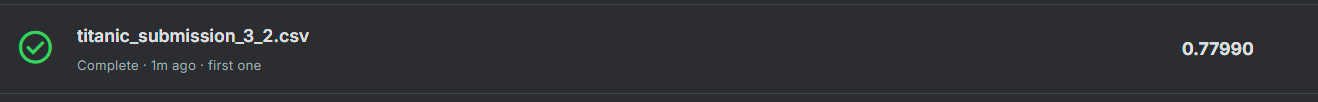
정확도를 3% 더 올려야한다는 슬픈사실..